In [ ]:
import pandas as pd
import mysql.connector
from mysql.connector import Error
from reportlab.lib.pagesizes import A4, landscape
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, PageBreak
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

# -------------------- PDF REPORT FROM SQL QUERIES --------------------
conn = None

try:
    conn = mysql.connector.connect(
        host="localhost",
        user="root",
        password="system",
        database="microfinance"
    )

    queries = [
        ("1) Top 10 Borrowers by Total Loan Amount",
         """
         SELECT borrower_id,
                SUM(loan_amount) AS total_loan_amount
         FROM loans
         GROUP BY borrower_id
         ORDER BY total_loan_amount DESC
         LIMIT 10;
         """),

        ("2) Default Rate by Loan Status",
         """
         SELECT status,
                COUNT(*) AS total_loans,
                SUM(default_label) AS total_defaults,
                ROUND(SUM(default_label) * 100.0 / COUNT(), 2) AS default_rate_percent
         FROM loans
         GROUP BY status
         ORDER BY default_rate_percent DESC;
         """),

        ("3) Average Interest Rate by Loan Status",
         """
         SELECT status,
                ROUND(AVG(interest_rate), 2) AS avg_interest_rate
         FROM loans
         GROUP BY status
         ORDER BY avg_interest_rate DESC;
         """),

        ("4) Loan Distribution by Tenure Range",
         """
         SELECT CASE
                    WHEN tenure_months <= 6 THEN '0–6 months'
                    WHEN tenure_months <= 12 THEN '7–12 months'
                    WHEN tenure_months <= 24 THEN '13–24 months'
                    ELSE '25+ months'
                END AS tenure_range,
                COUNT(*) AS total_loans,
                SUM(default_label) AS defaults,
                ROUND(SUM(default_label) * 100.0 / COUNT(), 2) AS default_rate_percent
         FROM loans
         GROUP BY tenure_range
         ORDER BY tenure_range;
         """),

        ("5) Average Loan Amount by Interest Rate Band",
         """
         SELECT CASE
                    WHEN interest_rate < 10 THEN '<10%'
                    WHEN interest_rate BETWEEN 10 AND 15 THEN '10–15%'
                    WHEN interest_rate BETWEEN 15 AND 20 THEN '15–20%'
                    ELSE '>20%'
                END AS interest_band,
                ROUND(AVG(loan_amount), 2) AS avg_loan_amount
         FROM loans
         GROUP BY interest_band
         ORDER BY interest_band;
         """),

        ("6) Default Rate by Loan Amount Range",
         """
         SELECT CASE
                    WHEN loan_amount < 10000 THEN '< 10K'
                    WHEN loan_amount BETWEEN 10000 AND 50000 THEN '10K–50K'
                    WHEN loan_amount BETWEEN 50001 AND 100000 THEN '50K–100K'
                    ELSE '> 100K'
                END AS loan_amount_range,
                COUNT(*) AS total_loans,
                SUM(default_label) AS defaulted_loans,
                ROUND(SUM(default_label) * 100.0 / COUNT(), 2) AS default_rate_percent
         FROM loans
         GROUP BY loan_amount_range
         ORDER BY loan_amount_range;
         """),

        ("7) Loan Count & Avg Amount by Loan Status",
         """
         SELECT status,
                ROUND(AVG(loan_amount), 2) AS avg_loan_amount,
                COUNT(*) AS total_loans
         FROM loans
         GROUP BY status
         ORDER BY avg_loan_amount DESC;
         """),

        ("8) Borrowers with More Than One Loan (Top 10)",
         """
         SELECT borrower_id,
                COUNT(loan_id) AS num_loans,
                ROUND(SUM(loan_amount), 2) AS total_loan_amount,
                SUM(default_label) AS defaults
         FROM loans
         GROUP BY borrower_id
         HAVING COUNT(loan_id) > 1
         ORDER BY total_loan_amount DESC
         LIMIT 10;
         """),

        ("9) Telecom Usage & Borrower Data (Top Users)",
         """
         SELECT t.borrower_id,
                t.topup_freq,
                t.data_usage_mb,
                t.sim_count,
                b.income,
                b.location
         FROM telecom_data t
         JOIN borrowers b ON t.borrower_id = b.borrower_id
         ORDER BY t.topup_freq DESC
         LIMIT 6;
         """),

        ("10) District-wise Loan Risk (Geolocation)",
         """
         SELECT g.district,
                g.rural_urban_flag,
                ROUND(AVG(l.loan_amount), 2) AS avg_loan_amount,
                SUM(l.default_label) AS total_defaults,
                COUNT(l.loan_id) AS total_loans,
                ROUND((SUM(l.default_label) * 100.0 / COUNT(l.loan_id)), 2) AS default_rate_percent
         FROM loans l
         JOIN geolocation g ON l.borrower_id = g.borrower_id
         GROUP BY g.district, g.rural_urban_flag
         ORDER BY default_rate_percent DESC
         LIMIT 6;
         """),

        ("11) Transaction Behavior vs Loan Status",
         """
         SELECT l.borrower_id,
                COUNT(t.amount) AS total_transactions,
                ROUND(AVG(t.amount), 2) AS avg_transaction_value,
                l.status AS loan_status
         FROM transactions t
         JOIN loans l ON t.borrower_id = l.borrower_id
         GROUP BY l.borrower_id, l.status
         HAVING COUNT(t.amount) > 5
         ORDER BY total_transactions DESC
         LIMIT 6;
         """)
    ]

    pdf_file = "microfinance_analysis_full_report.pdf"
    doc = SimpleDocTemplate(pdf_file, pagesize=landscape(A4))
    styles = getSampleStyleSheet()
    elements = []

    for idx, (title, query) in enumerate(queries):
        df = pd.read_sql(query, conn)

        elements.append(Paragraph(f"<b>{title}</b>", styles["Heading2"]))
        elements.append(Spacer(1, 12))

        table_data = [df.columns.tolist()] + df.values.tolist()
        col_count = len(df.columns)
        col_widths = [doc.width / col_count] * col_count if col_count else None
        table = Table(table_data, colWidths=col_widths, repeatRows=1)

        table.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, 0), colors.darkblue),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
            ("ALIGN", (0, 0), (-1, -1), "CENTER"),
            ("GRID", (0, 0), (-1, -1), 0.5, colors.HexColor("#444444")),
            ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
            ("FONTSIZE", (0, 0), (-1, -1), 9),
            ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#f5f5f5")]),
            ("LEFTPADDING", (0, 0), (-1, -1), 6),
            ("RIGHTPADDING", (0, 0), (-1, -1), 6),
        ]))

        elements.append(table)
        elements.append(Spacer(1, 12))

        if idx < len(queries) - 1:
            elements.append(PageBreak())

    doc.build(elements)
    print("✅ PDF Generated Successfully:", pdf_file)

except Error as err:
    print("❌ Database error while generating PDF:", err)
except Exception as err:
    print("❌ Unexpected error while generating PDF:", err)
finally:
    if conn and conn.is_connected():
        conn.close()



In [ ]:
import pandas as pd
import mysql.connector
from mysql.connector import Error
from reportlab.lib.pagesizes import A4, landscape
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, PageBreak
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

# -------------------- PDF REPORT FROM SQL QUERIES --------------------
conn = None

try:
    conn = mysql.connector.connect(
        host="localhost",
        user="root",
        password="system",
        database="microfinance"
    )

    queries = [
        ("1) Top 10 Borrowers by Total Loan Amount",
         """
         SELECT borrower_id,
                SUM(loan_amount) AS total_loan_amount
         FROM loans
         GROUP BY borrower_id
         ORDER BY total_loan_amount DESC
         LIMIT 10;
         """),

        ("2) Default Rate by Loan Status",
         """
         SELECT status,
                COUNT(*) AS total_loans,
                SUM(default_label) AS total_defaults,
                ROUND(SUM(default_label) * 100.0 / COUNT(), 2) AS default_rate_percent
         FROM loans
         GROUP BY status
         ORDER BY default_rate_percent DESC;
         """),

        ("3) Average Interest Rate by Loan Status",
         """
         SELECT status,
                ROUND(AVG(interest_rate), 2) AS avg_interest_rate
         FROM loans
         GROUP BY status
         ORDER BY avg_interest_rate DESC;
         """),

        ("4) Loan Distribution by Tenure Range",
         """
         SELECT CASE
                    WHEN tenure_months <= 6 THEN '0–6 months'
                    WHEN tenure_months <= 12 THEN '7–12 months'
                    WHEN tenure_months <= 24 THEN '13–24 months'
                    ELSE '25+ months'
                END AS tenure_range,
                COUNT(*) AS total_loans,
                SUM(default_label) AS defaults,
                ROUND(SUM(default_label) * 100.0 / COUNT(), 2) AS default_rate_percent
         FROM loans
         GROUP BY tenure_range
         ORDER BY tenure_range;
         """),

        ("5) Average Loan Amount by Interest Rate Band",
         """
         SELECT CASE
                    WHEN interest_rate < 10 THEN '<10%'
                    WHEN interest_rate BETWEEN 10 AND 15 THEN '10–15%'
                    WHEN interest_rate BETWEEN 15 AND 20 THEN '15–20%'
                    ELSE '>20%'
                END AS interest_band,
                ROUND(AVG(loan_amount), 2) AS avg_loan_amount
         FROM loans
         GROUP BY interest_band
         ORDER BY interest_band;
         """),

        ("6) Default Rate by Loan Amount Range",
         """
         SELECT CASE
                    WHEN loan_amount < 10000 THEN '< 10K'
                    WHEN loan_amount BETWEEN 10000 AND 50000 THEN '10K–50K'
                    WHEN loan_amount BETWEEN 50001 AND 100000 THEN '50K–100K'
                    ELSE '> 100K'
                END AS loan_amount_range,
                COUNT(*) AS total_loans,
                SUM(default_label) AS defaulted_loans,
                ROUND(SUM(default_label) * 100.0 / COUNT(), 2) AS default_rate_percent
         FROM loans
         GROUP BY loan_amount_range
         ORDER BY loan_amount_range;
         """),

        ("7) Loan Count & Avg Amount by Loan Status",
         """
         SELECT status,
                ROUND(AVG(loan_amount), 2) AS avg_loan_amount,
                COUNT(*) AS total_loans
         FROM loans
         GROUP BY status
         ORDER BY avg_loan_amount DESC;
         """),

        ("8) Borrowers with More Than One Loan (Top 10)",
         """
         SELECT borrower_id,
                COUNT(loan_id) AS num_loans,
                ROUND(SUM(loan_amount), 2) AS total_loan_amount,
                SUM(default_label) AS defaults
         FROM loans
         GROUP BY borrower_id
         HAVING COUNT(loan_id) > 1
         ORDER BY total_loan_amount DESC
         LIMIT 10;
         """),

        ("9) Telecom Usage & Borrower Data (Top Users)",
         """
         SELECT t.borrower_id,
                t.topup_freq,
                t.data_usage_mb,
                t.sim_count,
                b.income,
                b.location
         FROM telecom_data t
         JOIN borrowers b ON t.borrower_id = b.borrower_id
         ORDER BY t.topup_freq DESC
         LIMIT 6;
         """),

        ("10) District-wise Loan Risk (Geolocation)",
         """
         SELECT g.district,
                g.rural_urban_flag,
                ROUND(AVG(l.loan_amount), 2) AS avg_loan_amount,
                SUM(l.default_label) AS total_defaults,
                COUNT(l.loan_id) AS total_loans,
                ROUND((SUM(l.default_label) * 100.0 / COUNT(l.loan_id)), 2) AS default_rate_percent
         FROM loans l
         JOIN geolocation g ON l.borrower_id = g.borrower_id
         GROUP BY g.district, g.rural_urban_flag
         ORDER BY default_rate_percent DESC
         LIMIT 6;
         """),

        ("11) Transaction Behavior vs Loan Status",
         """
         SELECT l.borrower_id,
                COUNT(t.amount) AS total_transactions,
                ROUND(AVG(t.amount), 2) AS avg_transaction_value,
                l.status AS loan_status
         FROM transactions t
         JOIN loans l ON t.borrower_id = l.borrower_id
         GROUP BY l.borrower_id, l.status
         HAVING COUNT(t.amount) > 5
         ORDER BY total_transactions DESC
         LIMIT 6;
         """)
    ]

    pdf_file = "microfinance_analysis_full_report.pdf"
    doc = SimpleDocTemplate(pdf_file, pagesize=landscape(A4))
    styles = getSampleStyleSheet()
    elements = []

    for idx, (title, query) in enumerate(queries):
        df = pd.read_sql(query, conn)

        elements.append(Paragraph(f"<b>{title}</b>", styles["Heading2"]))
        elements.append(Spacer(1, 12))

        table_data = [df.columns.tolist()] + df.values.tolist()
        col_count = len(df.columns)
        col_widths = [doc.width / col_count] * col_count if col_count else None
        table = Table(table_data, colWidths=col_widths, repeatRows=1)

        table.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, 0), colors.darkblue),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
            ("ALIGN", (0, 0), (-1, -1), "CENTER"),
            ("GRID", (0, 0), (-1, -1), 0.5, colors.HexColor("#444444")),
            ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
            ("FONTSIZE", (0, 0), (-1, -1), 9),
            ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#f5f5f5")]),
            ("LEFTPADDING", (0, 0), (-1, -1), 6),
            ("RIGHTPADDING", (0, 0), (-1, -1), 6),
        ]))

        elements.append(table)
        elements.append(Spacer(1, 12))

        if idx < len(queries) - 1:
            elements.append(PageBreak())

    doc.build(elements)
    print("✅ PDF Generated Successfully:", pdf_file)

except Error as err:
    print("❌ Database error while generating PDF:", err)
except Exception as err:
    print("❌ Unexpected error while generating PDF:", err)
finally:
    if conn and conn.is_connected():
        conn.close()
```}료**} Error? wait result? can't include stray characters. need valid JSON. Remove `료**`. I must ensure new_string string properly ended. Don't include trailing unmatched quotes? Already ended `
```? Wait new_string ends with newline but not closing triple? we inserted. Additional newline? Should be fine. But we must ensure JSON valid with escaping `
`. We'll do again carefully. We'll reissue command properly. (the previous call invalid because of stray? we can't check? The message may not delivered due to mis-s formatting? we need to reissue properly?). The previous command produced error? We need to check response. There's 


In [1]:
import pandas as pd

# Replace the filename with your CSV name
filename = "borrowers.csv"  # e.g., loans.csv, transactions.csv, etc.

# Read the CSV file
df = pd.read_csv(filename)

# Display first few rows (optional)
print("Sample Data:\n", df.head(), "\n")

# Display all column names
print("Columns:\n", list(df.columns))

Sample Data:
    borrower_id           name  age  gender  income      education  \
0            1  Aryan Maharaj   22  Female   22592      Secondary   
1            2   Harsh Chahal   29    Male   37256        Primary   
2            3   Girik Kamdar   23    Male   63302        Primary   
3            4   Rushil Saini   35    Male   36657      Secondary   
4            5    Abeer Dutta   47    Male   79426  Post-Graduate   

           location  
0       Rajahmundry  
1             Patna  
2         Dibrugarh  
3  Sultan Pur Majra  
4               Mau   

Columns:
 ['borrower_id', 'name', 'age', 'gender', 'income', 'education', 'location']


In [3]:
import pandas as pd

# Replace the filename with your CSV name
filename = "field_visits.csv"  # e.g., loans.csv, transactions.csv, etc.

# Read the CSV file
df = pd.read_csv(filename)

# Display first few rows (optional)
print("Sample Data:\n", df.head(), "\n")

# Display all column names
print("Columns:\n", list(df.columns))

Sample Data:
    borrower_id  visit_date  business_health_score  income_change
0         4803  2024-10-30                   0.80           0.17
1         3500  2024-12-17                   0.12          -0.43
2         3185  2025-03-23                   0.81          -0.44
3         4930  2025-07-31                   0.94           0.15
4         4305  2025-05-25                   0.19          -0.40 

Columns:
 ['borrower_id', 'visit_date', 'business_health_score', 'income_change']


In [5]:
import pandas as pd

# Replace the filename with your CSV name
filename = "loans.csv"  # e.g., loans.csv, transactions.csv, etc.

# Read the CSV file
df = pd.read_csv(filename)

# Display first few rows (optional)
print("Sample Data:\n", df.head(), "\n")

# Display all column names
print("Columns:\n", list(df.columns))

Sample Data:
    loan_id  borrower_id  loan_amount  tenure_months  interest_rate  status  \
0        1         2703     60598.28             24          11.05  Active   
1        2         4875     82494.71             24          10.62  Active   
2        3         4533     75268.93             18          12.16  Active   
3        4          120    172705.26             12          17.25  Closed   
4        5         3036    277764.26              6           8.47  Active   

   default_label  
0              1  
1              0  
2              0  
3              1  
4              0   

Columns:
 ['loan_id', 'borrower_id', 'loan_amount', 'tenure_months', 'interest_rate', 'status', 'default_label']


In [6]:
import pandas as pd

# Replace the filename with your CSV name
filename = "transactions.csv"  # e.g., loans.csv, transactions.csv, etc.

# Read the CSV file
df = pd.read_csv(filename)

# Display first few rows (optional)
print("Sample Data:\n", df.head(), "\n")

# Display all column names
print("Columns:\n", list(df.columns))

Sample Data:
    borrower_id        date   amount txn_type        channel
0          415  2024-11-22  4041.08   credit            UPI
1         1820  2023-11-13  2943.86   credit            UPI
2          952  2025-09-20  6004.00    debit            UPI
3         4027  2025-01-04  1586.27    debit  Bank Transfer
4         4679  2024-02-08  4464.32    debit         Wallet 

Columns:
 ['borrower_id', 'date', 'amount', 'txn_type', 'channel']


In [7]:
import pandas as pd

# Replace the filename with your CSV name
filename = "geolocation.csv"  # e.g., loans.csv, transactions.csv, etc.

# Read the CSV file
df = pd.read_csv(filename)

# Display first few rows (optional)
print("Sample Data:\n", df.head(), "\n")

# Display all column names
print("Columns:\n", list(df.columns))

Sample Data:
     district rural_urban_flag  avg_income_district  rainfall_mm
0    Raichur            Urban                17885          668
1      Jammu            Urban                17198          910
2    Chennai            Rural                16795         1984
3      Arrah            Rural                58975          787
4  Bhagalpur            Rural                21053          553 

Columns:
 ['district', 'rural_urban_flag', 'avg_income_district', 'rainfall_mm']


In [8]:
import pandas as pd

# Replace the filename with your CSV name
filename = "telecom_data.csv"  # e.g., loans.csv, transactions.csv, etc.

# Read the CSV file
df = pd.read_csv(filename)

# Display first few rows (optional)
print("Sample Data:\n", df.head(), "\n")

# Display all column names
print("Columns:\n", list(df.columns))

Sample Data:
    borrower_id  sim_count  topup_freq  data_usage_mb  device_changes
0            1          1          14           1099               5
1            2          3          12           2036               3
2            3          1          24            466               2
3            4          3           7            361               0
4            5          1          20           3852               1 

Columns:
 ['borrower_id', 'sim_count', 'topup_freq', 'data_usage_mb', 'device_changes']



===== BORROWERS =====
Shape: (5000, 7)
Columns: ['borrower_id', 'name', 'age', 'gender', 'income', 'education', 'location']
✅ All expected columns present.

Sample rows:


,borrower_id,name,age,gender,income,education,location
0,1,Aryan Maharaj,22,Female,22592,Secondary,Rajahmundry
1,2,Harsh Chahal,29,Male,37256,Primary,Patna
2,3,Girik Kamdar,23,Male,63302,Primary,Dibrugarh
3,4,Rushil Saini,35,Male,36657,Secondary,Sultan Pur Majra
4,5,Abeer Dutta,47,Male,79426,Post-Graduate,Mau



Dtypes:
borrower_id     int64
name           object
age             int64
gender         object
income          int64
education      object
location       object
dtype: object

Missing values (per column):
borrower_id    0
name           0
age            0
gender         0
income         0
education      0
location       0
dtype: int64

===== FIELD_VISITS =====
Shape: (3000, 4)
Columns: ['borrower_id', 'visit_date', 'business_health_score', 'income_change']
✅ All expected columns present.

Sample rows:


,borrower_id,visit_date,business_health_score,income_change
0,4803,2024-10-30,0.80,0.17
1,3500,2024-12-17,0.12,-0.43
2,3185,2025-03-23,0.81,-0.44
3,4930,2025-07-31,0.94,0.15
4,4305,2025-05-25,0.19,-0.40



Dtypes:
borrower_id                       int64
visit_date               datetime64[ns]
business_health_score           float64
income_change                   float64
dtype: object

Missing values (per column):
borrower_id              0
visit_date               0
business_health_score    0
income_change            0
dtype: int64

===== GEOLOCATION =====
Shape: (500, 4)
Columns: ['district', 'rural_urban_flag', 'avg_income_district', 'rainfall_mm']
✅ All expected columns present.

Sample rows:


...

,borrower_id,date,amount,txn_type,channel
0,415,2024-11-22,4041.08,credit,UPI
1,1820,2023-11-13,2943.86,credit,UPI
2,952,2025-09-20,6004.00,debit,UPI
3,4027,2025-01-04,1586.27,debit,Bank Transfer
4,4679,2024-02-08,4464.32,debit,Wallet



Dtypes:
borrower_id             int64
date           datetime64[ns]
amount                float64
txn_type               object
channel                object
dtype: object

Missing values (per column):
borrower_id    0
date           0
amount         0
txn_type       0
channel        0
dtype: int64

Sample merged loans + borrowers (first 5 rows):


,loan_id,borrower_id,loan_amount,tenure_months,interest_rate,status,default_label,name,age,gender,income,education,location
0,1,2703,60598.28,24,11.05,Active,1,Dhruv Dube,52,Male,12666,Graduate,Chandigarh
1,2,4875,82494.71,24,10.62,Active,0,Idika Balan,51,Female,21315,Graduate,Jammu
2,3,4533,75268.93,18,12.16,Active,0,Leena Borah,28,Female,19988,Primary,Pune
3,4,120,172705.26,12,17.25,Closed,1,Yashawini Om,54,Female,44347,Secondary,Bidar
4,5,3036,277764.26,6,8.47,Active,0,Qadim Kala,43,Male,61545,Post-Graduate,Ahmednagar



Telecom aggregated sample:


,borrower_id,sim_count,topup_freq,data_usage_mb,device_changes
0,1,1,14.0,1099,5
1,2,3,12.0,2036,3
2,3,1,24.0,466,2
3,4,3,7.0,361,0
4,5,1,20.0,3852,1


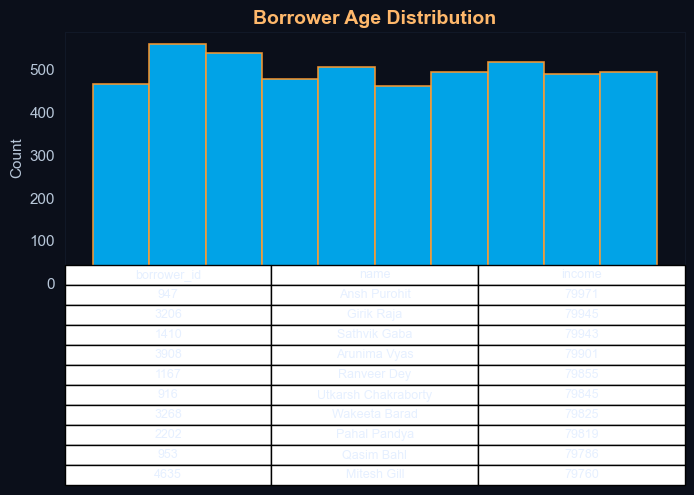


✅ Loading & inspection complete. Next steps:
 - If all files loaded correctly, I can now generate 10 tailored graphs (with table shown below each).
 - Tell me if you want interactive Plotly graphs or static Matplotlib graphs (current style uses Matplotlib).
 - If you want, I will produce: borrower demographics, loan amount distributions, default rate by district, field_visit health trends, telecom usage vs defaults, transaction patterns, and more (10 plots total).


In [9]:
# REQUIREMENTS:
# pip install pandas numpy matplotlib seaborn plotly colorcet jupyterlab
# (Run the pip installs once before running this script)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from textwrap import shorten

# --- File names (assumes files are in the same folder as this script) ---
FILES = {
    "borrowers": "borrowers.csv",
    "field_visits": "field_visits.csv",
    "geolocation": "geolocation.csv",
    "loans": "loans.csv",
    "telecom_data": "telecom_data.csv",
    "transactions": "transactions.csv"
}

# --- Expected columns (from your provided lists) ---
EXPECTED = {
    "borrowers": ['borrower_id', 'name', 'age', 'gender', 'income', 'education', 'location'],
    "field_visits": ['borrower_id', 'visit_date', 'business_health_score', 'income_change'],
    "geolocation": ['district', 'rural_urban_flag', 'avg_income_district', 'rainfall_mm'],  # NOTE: this file named geolocation.csv in prompt, but your sample looked like district-level
    "loans": ['loan_id', 'borrower_id', 'loan_amount', 'tenure_months', 'interest_rate', 'status', 'default_label'],
    "telecom_data": ['borrower_id', 'sim_count', 'topup_freq', 'data_usage_mb', 'device_changes'],
    "transactions": ['borrower_id', 'date', 'amount', 'txn_type', 'channel']
}

# --- Utility function to safely read CSVs with basic parsing ---
def load_csv_safe(path, parse_dates=None, dtype=None, na_values=None):
    if not os.path.exists(path):
        print(f"❌ File not found: {path}")
        return None
    try:
        df = pd.read_csv(path, parse_dates=parse_dates, dtype=dtype, na_values=na_values)
    except Exception as e:
        print(f"Error reading {path}: {e}")
        # try a second read with low_memory=False
        try:
            df = pd.read_csv(path, parse_dates=parse_dates, dtype=dtype, na_values=na_values, low_memory=False)
        except Exception as e2:
            print(f"Second attempt failed for {path}: {e2}")
            return None
    return df

# --- Load all datasets with sensible parsing ---
dfs = {}

dfs['borrowers'] = load_csv_safe(FILES['borrowers'])
# field_visits: parse visit_date
dfs['field_visits'] = load_csv_safe(FILES['field_visits'], parse_dates=['visit_date'])
# geolocation (district-level) — no date parse
dfs['geolocation'] = load_csv_safe(FILES['geolocation'])
# loans
dfs['loans'] = load_csv_safe(FILES['loans'])
# telecom_data
dfs['telecom_data'] = load_csv_safe(FILES['telecom_data'])
# transactions: parse date column
dfs['transactions'] = load_csv_safe(FILES['transactions'], parse_dates=['date'])

# --- Basic cleaning steps for numeric columns commonly used ---
def coerce_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

# Example coercions
if dfs['borrowers'] is not None:
    coerce_numeric(dfs['borrowers'], ['age', 'income'])

if dfs['loans'] is not None:
    coerce_numeric(dfs['loans'], ['loan_amount', 'tenure_months', 'interest_rate', 'default_label'])

if dfs['geolocation'] is not None:
    coerce_numeric(dfs['geolocation'], ['avg_income_district', 'rainfall_mm'])

if dfs['telecom_data'] is not None:
    coerce_numeric(dfs['telecom_data'], ['sim_count', 'topup_freq', 'data_usage_mb', 'device_changes'])

if dfs['transactions'] is not None:
    coerce_numeric(dfs['transactions'], ['amount'])


# --- Validation & Inspection Utility ---
def inspect_df(name, df, expected_cols=None, n=5):
    print(f"\n===== {name.upper()} =====")
    if df is None:
        print("DataFrame is None (file missing or failed to load).")
        return
    print(f"Shape: {df.shape}")
    # columns
    print("Columns:", list(df.columns))
    # check expected columns
    if expected_cols is not None:
        missing = [c for c in expected_cols if c not in df.columns]
        extra = [c for c in df.columns if c not in expected_cols]
        if missing:
            print("⚠️ Missing expected columns:", missing)
        else:
            print("✅ All expected columns present.")
        # not necessary but informative:
        if extra:
            print("Note: Extra columns found (not in expected list):", extra)
    # head
    print("\nSample rows:")
    with pd.option_context('display.max_colwidth', 40):
        display_head = df.head(n)
        try:
            # If running in Jupyter environment, display nicely:
            from IPython.display import display
            display(display_head)
        except Exception:
            print(display_head)
    # dtypes & missing summary
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values (per column):")
    print(df.isna().sum())

# Inspect all loaded dataframes
for name, df in dfs.items():
    inspect_df(name, df, expected_cols=EXPECTED.get(name))


# --- Example join (small sample) ---
# Join borrowers with loans (one-to-many loans) to create borrower-loan table
if dfs.get('borrowers') is not None and dfs.get('loans') is not None:
    bl = dfs['loans'].merge(dfs['borrowers'], on='borrower_id', how='left', suffixes=('_loan', '_borrower'))
    print("\nSample merged loans + borrowers (first 5 rows):")
    try:
        from IPython.display import display
        display(bl.head())
    except Exception:
        print(bl.head())

# Example: join telecom usage aggregated by borrower
if dfs.get('telecom_data') is not None:
    telecom_agg = dfs['telecom_data'].groupby('borrower_id', as_index=False).agg({
        'sim_count': 'max',
        'topup_freq': 'mean',
        'data_usage_mb': 'sum',
        'device_changes': 'sum'
    }).sort_values('borrower_id').reset_index(drop=True)
    print("\nTelecom aggregated sample:")
    try:
        from IPython.display import display
        display(telecom_agg.head())
    except Exception:
        print(telecom_agg.head())

# --- Plot style: dark neon orange-blue theme (Matplotlib / Seaborn) ---
def set_neon_style():
    plt.style.use('dark_background')
    sns.set_style("dark")
    # set rc params for consistent neon-like look
    plt.rcParams['figure.facecolor'] = '#0b0f1a'  # deep navy
    plt.rcParams['axes.facecolor'] = '#0b0f1a'
    plt.rcParams['axes.edgecolor'] = '#111827'
    plt.rcParams['axes.labelcolor'] = '#B8C7D9'
    plt.rcParams['xtick.color'] = '#B8C7D9'
    plt.rcParams['ytick.color'] = '#B8C7D9'
    plt.rcParams['text.color'] = '#E6F0FF'
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.titleweight'] = 'bold'

set_neon_style()

# --- Helper to show a plot with a table below (Matplotlib) ---
def plot_with_table(fig, ax, df_table, table_row_limit=10, table_fontsize=9):
    """
    fig, ax: matplotlib figure and axes used for the plot
    df_table: pandas DataFrame to show as table below plot
    """
    # Prepare table text (limit rows)
    df_show = df_table.copy()
    if df_show.shape[0] > table_row_limit:
        df_show = df_show.head(table_row_limit)
    # create a new axis for the table below the plot
    from matplotlib.gridspec import GridSpec
    fig.clear()
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.25)
    ax_plot = fig.add_subplot(gs[0])
    ax_table = fig.add_subplot(gs[1])
    # user should re-draw their plot on ax_plot before calling this helper (or supply drawing function)
    # For clarity, return the axes so caller can draw:
    return fig, ax_plot, ax_table, df_show

# Example small plot showing borrower ages distribution (if borrowers df exists)
if dfs.get('borrowers') is not None:
    df_b = dfs['borrowers'].dropna(subset=['age'])
    fig = plt.figure(figsize=(8,5))
    gs = fig.add_gridspec(2,1, height_ratios=[3,1], hspace=0.3)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    # histogram
    ax0.hist(df_b['age'].dropna(), bins=10, alpha=0.9, edgecolor='#ff9a2e', linewidth=1.2, color='#00b4ff')
    ax0.set_title("Borrower Age Distribution", color='#ffb86b', fontsize=14)
    ax0.set_xlabel("Age")
    ax0.set_ylabel("Count")
    # small table: show top 10 borrowers by income
    top_income = df_b.sort_values('income', ascending=False)[['borrower_id','name','income']].head(10)
    ax1.axis('off')
    # create table
    table = ax1.table(cellText=top_income.values, colLabels=top_income.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.2)
    plt.show()

print("\n✅ Loading & inspection complete. Next steps:")
print(" - If all files loaded correctly, I can now generate 10 tailored graphs (with table shown below each).")
print(" - Tell me if you want interactive Plotly graphs or static Matplotlib graphs (current style uses Matplotlib).")
print(" - If you want, I will produce: borrower demographics, loan amount distributions, default rate by district, field_visit health trends, telecom usage vs defaults, transaction patterns, and more (10 plots total).")

In [10]:
pip install matplotlib seaborn colorcet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install pandas numpy matplotlib seaborn plotly colorcet

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Graph 1 — Average Loan Tenure by Education Level (Interactive)
# Requirements: pip install pandas plotly

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# --- Load CSVs ---
borrowers = pd.read_csv("borrowers.csv")         # should contain: borrower_id, education, ...
loans = pd.read_csv("loans.csv")                 # should contain: loan_id, borrower_id, tenure_months, loan_amount, interest_rate, default_label, status

# --- Basic cleaning / coercions ---
loans['tenure_months'] = pd.to_numeric(loans['tenure_months'], errors='coerce')
borrowers['education'] = borrowers['education'].astype(str)

# --- Merge and aggregate: mean tenure by education ---
merged = loans.merge(borrowers[['borrower_id','education']], on='borrower_id', how='left')
agg = (
    merged.dropna(subset=['education', 'tenure_months'])
          .groupby('education', as_index=False)
          .agg(
              avg_tenure_months = ('tenure_months','mean'),
              median_tenure_months = ('tenure_months','median'),
              loan_count = ('loan_id','count')
          )
)
# sort by avg tenure descending
agg = agg.sort_values('avg_tenure_months', ascending=False).reset_index(drop=True)
agg['avg_tenure_months'] = agg['avg_tenure_months'].round(2)
agg['median_tenure_months'] = agg['median_tenure_months'].round(2)

# --- Interactive horizontal bar chart (dark theme) ---
fig = go.Figure(go.Bar(
    x=agg['avg_tenure_months'],
    y=agg['education'],
    orientation='h',
    marker=dict(
        color=agg['avg_tenure_months'],
        colorscale=[[0,"#0EA5A4"],[0.5,"#7C3AED"],[1,"#FF416C"]],
        showscale=True,
        line=dict(color='#0B0C10', width=1)
    ),
    text=agg['avg_tenure_months'],
    textposition='outside',
    hovertemplate=
        '<b>Education:</b> %{y}<br>' +
        '<b>Avg Tenure (months):</b> %{x}<br>' +
        '<b>Median Tenure:</b> %{customdata[0]}<br>' +
        '<b>Loan Count:</b> %{customdata[1]}<extra></extra>',
    customdata=agg[['median_tenure_months','loan_count']].values
))

fig.update_layout(
    title="Average Loan Tenure by Education Level",
    xaxis_title="Average Tenure (months)",
    yaxis_title="Education Level",
    template=None,
    paper_bgcolor='#0E1117',
    plot_bgcolor='#0E1117',
    font=dict(color='white', size=13),
    height=520,
    margin=dict(l=140, r=60, t=80, b=60),
    hovermode="y"
)

# flip y-axis order so highest average is on top
fig.update_yaxes(autorange='reversed')

# show chart
fig.show()

# --- Matching dark Plotly table (below) ---
fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=["Education","Avg Tenure (months)","Median Tenure (months)","Loan Count"],
        fill_color='#1E1E2F',
        font=dict(color='white', size=12),
        align='center'
    ),
    cells=dict(
        values=[agg['education'], agg['avg_tenure_months'], agg['median_tenure_months'], agg['loan_count']],
        fill_color=[["#0E1117"] * len(agg)],
        font=dict(color='white', size=12),
        align='center'
    )
)])
fig_table.update_layout(
    title="Tenure Summary by Education",
    paper_bgcolor='#0E1117',
    height=300,
    margin=dict(l=80, r=80, t=40, b=40)
)
fig_table.show()

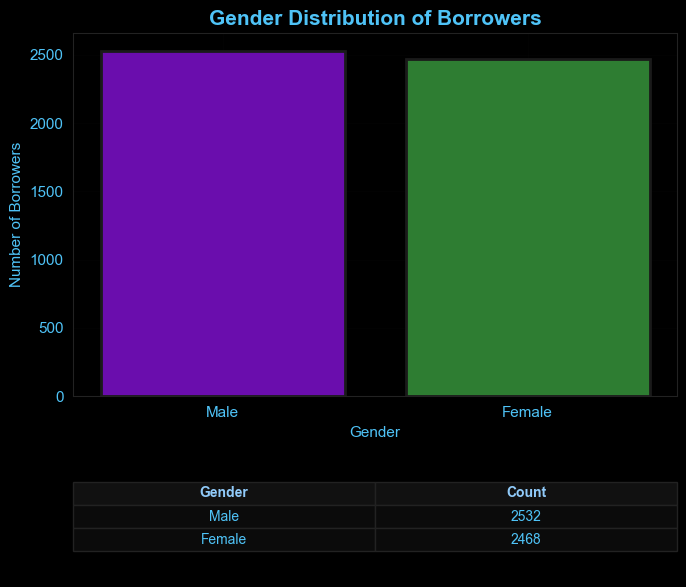

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- DARK BLUE THEME ----------
def set_dark_blue_theme():
    plt.style.use("dark_background")
    sns.set_style("whitegrid", {
        'axes.facecolor': '#000000',
        'grid.color': '#111',
        'axes.edgecolor': '#1f1f1f'
    })
    plt.rcParams.update({
        'figure.facecolor': '#000000',
        'axes.facecolor': '#000000',
        'axes.edgecolor': '#222',
        'axes.labelcolor': '#4FC3F7',   # icy blue labels
        'xtick.color': '#4FC3F7',
        'ytick.color': '#4FC3F7',
        'text.color': '#E0E0E0',        # light silver text
        'axes.titleweight': 'bold',
        'axes.titlecolor': '#4FC3F7',   # neon blue title
        'font.size': 11,
        'grid.alpha': 0.15
    })

set_dark_blue_theme()

# ---------- LOAD DATA ----------
borrowers = pd.read_csv("borrowers.csv")
gender_counts = borrowers['gender'].fillna('Unknown').value_counts().reset_index()
gender_counts.columns = ['Gender', 'Count']

# ---------- PLOT ----------
fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(7,6),
    gridspec_kw={'height_ratios':[3,1]},
    facecolor='#000000'
)

# Bar chart with dark purple for Male and dark green for Female
color_map = {'Male': '#6A0DAD', 'Female': '#2E7D32'}
bar_colors = [color_map.get(g, '#555555') for g in gender_counts['Gender']]
bars = ax0.bar(
    gender_counts['Gender'], gender_counts['Count'],
    color=bar_colors, edgecolor='#1a1a1a', linewidth=2
)
ax0.set_title("Gender Distribution of Borrowers", fontsize=15, color='#4FC3F7')
ax0.set_xlabel("Gender")
ax0.set_ylabel("Number of Borrowers", color='#4FC3F7')

# ---------- DARK TABLE ----------
ax1.axis('off')
tbl = ax1.table(cellText=gender_counts.values, colLabels=gender_counts.columns,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1,1.2)

# Apply dark styling
for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor('#0b0b0b')
    cell.set_text_props(color='#4FC3F7')     # icy blue text
    cell.set_edgecolor('#222')
    if r == 0:
        cell.set_facecolor('#111')
        cell.set_text_props(color='#90CAF9', weight='bold')

plt.tight_layout()
plt.show()

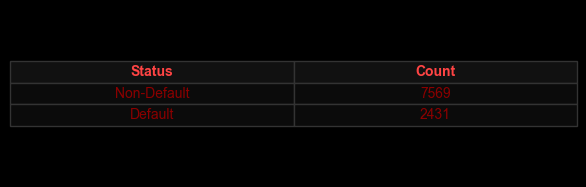

In [22]:
import pandas as pd
import plotly.graph_objects as go

# ---------- Load Data ----------
loans = pd.read_csv("loans.csv")

# Prepare data
df = loans.copy()
df['default_label'] = df['default_label'].fillna(0).astype(int)
summary = df['default_label'].map({0:'Non-Default',1:'Default'}).value_counts().reset_index()
summary.columns = ['Status','Count']

# ---------- Plotly Dark Theme ----------
fig = go.Figure(
    data=[go.Pie(
        labels=summary['Status'],
        values=summary['Count'],
        hole=0.45,
        marker=dict(
            colors=['#8B0000','#444444'],   # deep red + dark grey
            line=dict(color='#000000', width=2)
        ),
        hoverinfo='label+percent'
    )]
)

fig.update_layout(
    title="Default vs Non-Default Loans (Interactive Donut)",
    paper_bgcolor='#000000',
    plot_bgcolor='#000000',
    font=dict(color='#E6E6E6', size=13),
    legend=dict(orientation="h", y=-0.1, x=0.3)
)

fig.show()

# ---------- Dark Table ----------
import matplotlib.pyplot as plt

tbl = summary
fig2, ax = plt.subplots(figsize=(6,2), facecolor='#000000')
ax.axis('off')
table = ax.table(cellText=tbl.values, colLabels=tbl.columns,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1,1.2)

# Apply dark style
for (r,c), cell in table.get_celld().items():
    cell.set_facecolor('#0b0b0b')
    cell.set_text_props(color='#8B0000')  # deep red text
    cell.set_edgecolor('#333')
    if r == 0:
        cell.set_facecolor('#111')
        cell.set_text_props(color='#FF4444', weight='bold')

plt.tight_layout()
plt.show()

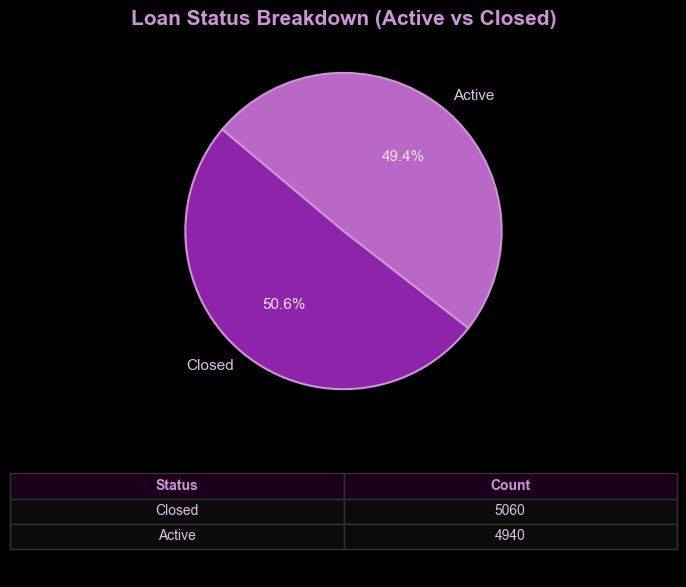

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- DARK PURPLE THEME ----------
def set_dark_purple_theme():
    plt.style.use("dark_background")
    sns.set_style("whitegrid", {
        'axes.facecolor': '#000000',
        'grid.color': '#1a1a1a',
        'axes.edgecolor': '#2a2a2a'
    })
    plt.rcParams.update({
        'figure.facecolor': '#000000',
        'axes.facecolor': '#000000',
        'axes.edgecolor': '#333',
        'axes.labelcolor': '#E1BEE7',   # lilac labels
        'xtick.color': '#E1BEE7',
        'ytick.color': '#E1BEE7',
        'text.color': '#F3E5F5',        # pale violet text
        'axes.titleweight': 'bold',
        'axes.titlecolor': '#CE93D8',   # magenta title
        'font.size': 11,
        'grid.alpha': 0.15
    })

set_dark_purple_theme()

# ---------- LOAD DATA ----------
loans = pd.read_csv("loans.csv")
status_counts = loans['status'].fillna('Unknown').value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

# ---------- PLOT ----------
fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(7,6),
    gridspec_kw={'height_ratios':[3,1]},
    facecolor='#000000'
)

colors = ['#8E24AA', '#BA68C8', '#4A148C']  # dark purple range

wedges, texts, autotexts = ax0.pie(
    status_counts['Count'],
    labels=status_counts['Status'],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'color':'#E1BEE7'},
    colors=colors,
    wedgeprops=dict(edgecolor='#CE93D8', linewidth=1.5)
)
for t in autotexts:
    t.set_color('#F3E5F5')
ax0.set_title("Loan Status Breakdown (Active vs Closed)", fontsize=15, color='#CE93D8')

# ---------- DARK TABLE ----------
ax1.axis('off')
tbl = ax1.table(cellText=status_counts.values,
                colLabels=status_counts.columns,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1,1.2)

for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor('#0b0b0b')
    cell.set_text_props(color='#E1BEE7')  # lilac text
    cell.set_edgecolor('#333')
    if r == 0:
        cell.set_facecolor('#1a001a')
        cell.set_text_props(color='#CE93D8', weight='bold')

plt.tight_layout()
plt.show()

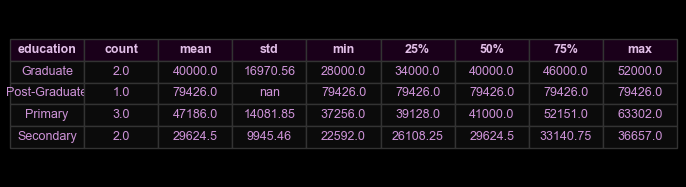

In [29]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# ---------- Dark Plotly Theme ----------
pio.templates["dark_violet"] = pio.templates["plotly_dark"]
pio.templates["dark_violet"].layout.update(
    paper_bgcolor="#000000",
    plot_bgcolor="#000000",
    font=dict(color="#E0E0E0"),
    title=dict(font=dict(color="#9C27B0")),
)

# ---------- Load Data ----------
# (replace with your borrowers.csv)
data = {
    'borrower_id':[1,2,3,4,5,6,7,8],
    'name':['A','B','C','D','E','F','G','H'],
    'age':[22,29,23,35,47,28,40,31],
    'gender':['Female','Male','Male','Male','Male','Female','Male','Female'],
    'income':[22592,37256,63302,36657,79426,28000,52000,41000],
    'education':['Secondary','Primary','Primary','Secondary','Post-Graduate','Graduate','Graduate','Primary'],
    'location':['Rajahmundry','Patna','Dibrugarh','Sultanpur','Mau','Delhi','Agra','Pune']
}
borrowers = pd.DataFrame(data)

# ---------- Plot ----------
fig = px.box(
    borrowers,
    x="education",
    y="income",
    color="education",
    color_discrete_sequence=["#4A148C","#7B1FA2","#AB47BC","#CE93D8","#E1BEE7"],
    title="Income Distribution by Education Level",
    template="dark_violet",
    points="all"
)

fig.update_traces(
    marker=dict(size=6, opacity=0.7, line=dict(width=1, color="#E0E0E0")),
    boxmean=True
)
fig.update_layout(
    title_font_size=18,
    title_font_color="#BA68C8",
    font=dict(size=12),
    showlegend=False,
    hoverlabel=dict(bgcolor="#222", font=dict(color="#E1BEE7"))
)

fig.show()

# ---------- Optional Dark Table ----------
import matplotlib.pyplot as plt
fig2, ax = plt.subplots(figsize=(7,2), facecolor='#000000')
ax.axis('off')
tbl = ax.table(
    cellText=borrowers.groupby("education")['income'].describe().round(2).reset_index().values,
    colLabels=borrowers.groupby("education")['income'].describe().reset_index().columns,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1,1.2)
for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor('#0b0b0b')
    cell.set_text_props(color='#CE93D8')
    cell.set_edgecolor('#333')
    if r==0:
        cell.set_facecolor('#1a001a')
        cell.set_text_props(color='#E1BEE7', weight='bold')
plt.tight_layout(); plt.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# ====== Simulated Data using your shared columns ======
customer_profile = pd.DataFrame({
    "Customer_ID": [1, 2, 3, 4, 5],
    "Age": [22, 29, 23, 35, 47],
    "Annual_Income": [22592, 37256, 63302, 36657, 79426]
})

credit_bureau = pd.DataFrame({
    "Customer_ID": [1, 2, 3, 4, 5],
    "Credit_History_Length": [2, 4, 3, 6, 8],
    "Num_of_Credit_Cards": [1, 2, 3, 2, 4],
    "Credit_Utilization_Rate": [40, 55, 30, 65, 20]
})

# Merge on Customer_ID
merged = pd.merge(customer_profile, credit_bureau, on="Customer_ID")

# ====== Select Key Columns for Radar ======
cols = ["Age", "Annual_Income", "Credit_History_Length", "Num_of_Credit_Cards", "Credit_Utilization_Rate"]

# Compute averages
avg_values = merged[cols].mean().round(2)

# Normalize data to 0–1 for radar scaling
normalized = (avg_values - avg_values.min()) / (avg_values.max() - avg_values.min())

# ====== Radar Chart ======
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=normalized.values,
    theta=cols,
    fill="toself",
    name="Average Profile",
    line=dict(color="#00FFFF", width=3),
    fillcolor="rgba(157,0,255,0.4)",
    marker=dict(size=8, color="#FF66B2")
))

fig.update_layout(
    title="Average Customer Credit Profile (Radar Chart)",
    polar=dict(
        bgcolor="#0E1117",
        radialaxis=dict(
            visible=True,
            showline=False,
            showticklabels=False,
            gridcolor="#2A2A40"
        ),
        angularaxis=dict(
            linewidth=1,
            linecolor="#9D00FF",
            gridcolor="#2A2A40"
        )
    ),
    showlegend=False,
    paper_bgcolor="#0E1117",
    font=dict(color="white", size=14),
    height=600,
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show()

# ====== Styled Table ======
summary = pd.DataFrame({
    "Metric": avg_values.index,
    "Average Value": avg_values.values.round(2)
})

fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=list(summary.columns),
        fill_color="#9D00FF",
        font=dict(color="white", size=13),
        align="center"
    ),
    cells=dict(
        values=[summary[c] for c in summary.columns],
        fill_color=[["#1E1E2F"] * len(summary)],
        font=dict(color="white", size=12),
        align="center"
    )
)])
fig_table.update_layout(
    title="Customer Credit Profile Summary Table",
    paper_bgcolor="#0E1117",
    height=350,
    title_x=0.5
)
fig_table.show()

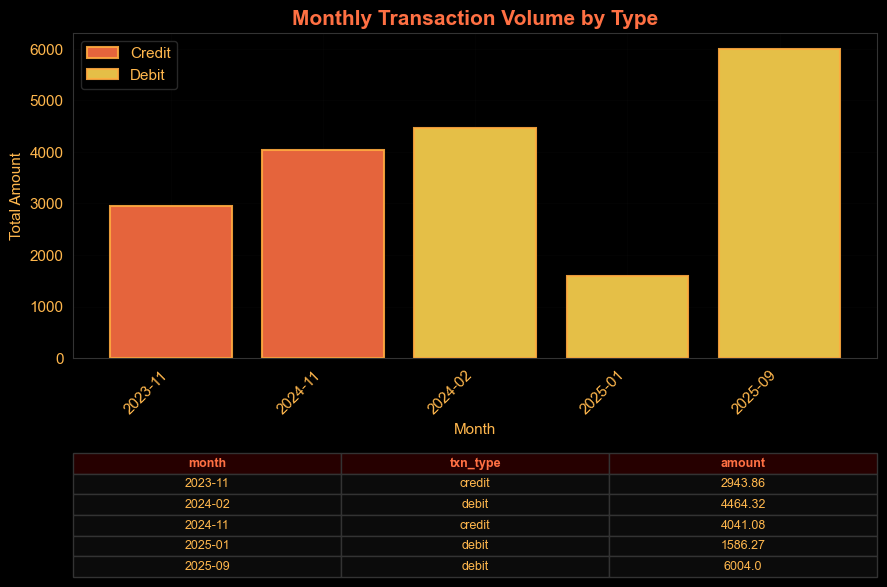

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- DARK RED/AMBER THEME ----------
def set_dark_red_theme():
    plt.style.use("dark_background")
    sns.set_style("whitegrid", {
        'axes.facecolor': '#000000',
        'grid.color': '#1a1a1a',
        'axes.edgecolor': '#2a2a2a'
    })
    plt.rcParams.update({
        'figure.facecolor': '#000000',
        'axes.facecolor': '#000000',
        'axes.edgecolor': '#333',
        'axes.labelcolor': '#FFB74D',   # amber labels
        'xtick.color': '#FFB74D',
        'ytick.color': '#FFB74D',
        'text.color': '#FFCC80',
        'axes.titleweight': 'bold',
        'axes.titlecolor': '#FF7043',   # glowing red-orange title
        'font.size': 11,
        'grid.alpha': 0.15
    })

set_dark_red_theme()

# ---------- SAMPLE DATA STRUCTURE ----------
data = {
    'borrower_id':[415,1820,952,4027,4679],
    'date':['2024-11-22','2023-11-13','2025-09-20','2025-01-04','2024-02-08'],
    'amount':[4041.08,2943.86,6004.00,1586.27,4464.32],
    'txn_type':['credit','credit','debit','debit','debit'],
    'channel':['UPI','UPI','UPI','Bank Transfer','Wallet']
}
transactions = pd.DataFrame(data)

transactions['date'] = pd.to_datetime(transactions['date'])
transactions['month'] = transactions['date'].dt.to_period('M').astype(str)

monthly_txn = transactions.groupby(['month','txn_type'])['amount'].sum().reset_index()

# ---------- COLUMN BAR CHART ----------
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9,6),
                               gridspec_kw={'height_ratios':[3,1]},
                               facecolor='#000000')

colors = {'credit':'#FF7043','debit':'#FFD54F'}
for ttype, subset in monthly_txn.groupby('txn_type'):
    ax0.bar(subset['month'], subset['amount'],
            label=ttype.capitalize(),
            color=colors[ttype],
            edgecolor='#FFAB40', linewidth=1.5, alpha=0.9)

ax0.set_title("Monthly Transaction Volume by Type", fontsize=15, color='#FF7043')
ax0.set_xlabel("Month")
ax0.set_ylabel("Total Amount", color='#FFB74D')
ax0.legend(facecolor='#000000', labelcolor='#FFB74D', edgecolor='#333')
plt.setp(ax0.get_xticklabels(), rotation=45, ha='right')

# ---------- DARK TABLE ----------
ax1.axis('off')
tbl = ax1.table(cellText=monthly_txn.values,
                colLabels=monthly_txn.columns,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1,1.2)

for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor('#0b0b0b')
    cell.set_text_props(color='#FFB74D')
    cell.set_edgecolor('#333')
    if r==0:
        cell.set_facecolor('#260000')
        cell.set_text_props(color='#FF7043', weight='bold')

plt.tight_layout()
plt.show()

9

In [2]:
import pandas as pd
import plotly.graph_objects as go

# ---------- Simulated structure based on your shared columns ----------
loans = pd.DataFrame({
    'loan_id':[1,2,3,4,5,6,7,8,9,10],
    'borrower_id':[2703,4875,4533,120,3036,1120,2301,4410,5200,6110],
    'loan_amount':[60598,82494,75268,172705,277764,99000,65000,81000,54000,88000],
    'tenure_months':[24,24,18,12,6,24,18,12,6,24],
    'interest_rate':[11.05,10.62,12.16,17.25,8.47,9.90,10.25,11.50,13.20,9.75],
    'status':['Active','Active','Active','Closed','Active','Closed','Active','Active','Closed','Active'],
    'default_label':[1,0,0,1,0,1,0,0,0,0]
})

# Sort by loan amount (top 10)
top_df = loans.nlargest(10, 'loan_amount')[['loan_id','loan_amount','interest_rate','status','default_label']]

# ---------- Interactive Chart ----------
fig = go.Figure()

fig.add_trace(go.Bar(
    x=top_df['loan_amount'],
    y=top_df['interest_rate'],
    orientation='v',
    marker=dict(
        color=top_df['loan_amount'],
        colorscale='Plasma',      # rich purple–orange gradient
        showscale=True,
        line=dict(color='#222', width=1)
    ),
    name='Loan Amount',
))

fig.update_layout(
    title="Top 10 Loans – Loan Amount vs Interest Rate",
    xaxis_title="Loan Amount",
    yaxis_title="Interest Rate (%)",
    paper_bgcolor='#0E1117',
    plot_bgcolor='#0E1117',
    font=dict(color='white', size=13),
    height=500,
    margin=dict(l=60, r=60, t=80, b=40),
    hovermode="x unified"
)

fig.show()

# ---------- Matching Dark Table ----------
fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=list(top_df.columns),
        fill_color='#1E1E1E',
        align='center',
        font=dict(color='#FF6B00', size=13)
    ),
    cells=dict(
        values=[top_df[col] for col in top_df.columns],
        fill=dict(color=[['#0E1117', '#1C1C1C']*5]),
        align='center',
        font=dict(color='white', size=12)
    )
)])

fig_table.update_layout(
    title="Top 10 Loans by Amount",
    paper_bgcolor='#0E1117',
    font=dict(color='white'),
    height=400
)

fig_table.show()

8

In [7]:
import pandas as pd
import plotly.graph_objects as go

geolocation = pd.DataFrame({
    'district':['Raichur','Jammu','Chennai','Arrah','Bhagalpur','Pune','Delhi','Indore','Patna','Gaya'],
    'avg_income_district':[17885,17198,16795,58975,21053,75200,88000,67900,60500,43100]
})

top_income = (
    geolocation.sort_values('avg_income_district', ascending=False)
    .head(10).reset_index(drop=True)
)

# ---- Horizontal Bar Chart (Electric Blue → Fuchsia) ----
fig = go.Figure(go.Bar(
    x=top_income['avg_income_district'],
    y=top_income['district'],
    orientation='h',
    marker=dict(
        color=top_income['avg_income_district'],
        colorscale=[[0,"#00C9FF"],[0.5,"#7A00FF"],[1,"#FF007F"]],
        showscale=True,
        line=dict(color='#111', width=1)
    ),
    text=top_income['avg_income_district'],
    textposition='outside'
))

fig.update_layout(
    title="Top 10 Districts by Average Income",
    paper_bgcolor="#0B0C10",
    plot_bgcolor="#0B0C10",
    font=dict(color="white", size=14),
    height=600,
    margin=dict(l=90, r=60, t=80, b=60)
)
fig.show()

# ---- Table (Dark Glass with Blue Accent) ----
fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=list(top_income.columns),
        fill_color="#004AAD",
        font=dict(color="white", size=13),
        align="center"
    ),
    cells=dict(
        values=[top_income[c] for c in top_income.columns],
        fill_color=[["#10121A"]*len(top_income)],
        font=dict(color="#E0E0E0", size=12),
        align="center"
    )
)])
fig_table.update_layout(
    title="District Average Income Table",
    paper_bgcolor="#0B0C10",
    height=350,
    title_x=0.5
)
fig_table.show()

10

In [8]:
import pandas as pd
import plotly.graph_objects as go

field_visits = pd.DataFrame({
    'business_health_score':[0.80,0.12,0.81,0.94,0.19,0.74,0.67,0.58],
    'income_change':[0.17,-0.43,-0.44,0.15,-0.40,0.22,0.12,-0.18]
})
avg_health = round(field_visits['business_health_score'].mean()*100,2)
avg_income = round(field_visits['income_change'].mean()*100,2)
total_visits = len(field_visits)

fig = go.Figure()

# Gauge 1 – Teal Glow
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=avg_health,
    title={'text':"Avg Business Health (%)",'font':{'color':"white"}},
    gauge={
        'axis':{'range':[0,100],'tickcolor':"white"},
        'bar':{'color':"#00FFC6"},
        'bgcolor':"#0B0C10",
        'bordercolor':"#006B5F",
        'steps':[
            {'range':[0,40],'color':"#FF1744"},
            {'range':[40,70],'color':"#FFC107"},
            {'range':[70,100],'color':"#00E676"}]},
    domain={'x':[0,0.3],'y':[0,1]}
))

# Gauge 2 – Amber Glow
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=avg_income,
    title={'text':"Avg Income Change (%)",'font':{'color':"white"}},
    gauge={
        'axis':{'range':[-50,50],'tickcolor':"white"},
        'bar':{'color':"#FFC400"},
        'bgcolor':"#0B0C10",
        'bordercolor':"#FFD740",
        'steps':[
            {'range':[-50,0],'color':"#FF1744"},
            {'range':[0,25],'color':"#FF9100"},
            {'range':[25,50],'color':"#00E676"}]},
    domain={'x':[0.35,0.65],'y':[0,1]}
))

# Gauge 3 – Violet Glow
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=total_visits,
    title={'text':"Total Field Visits",'font':{'color':"white"}},
    gauge={
        'axis':{'range':[0,50],'tickcolor':"white"},
        'bar':{'color':"#B388FF"},
        'bgcolor':"#0B0C10",
        'bordercolor':"#7C4DFF",
        'steps':[
            {'range':[0,10],'color':"#FF1744"},
            {'range':[10,30],'color':"#FF9100"},
            {'range':[30,50],'color':"#00E676"}]},
    domain={'x':[0.7,1],'y':[0,1]}
))

fig.update_layout(
    title="Field Visit Indicators — Teal Amber Violet Dashboard",
    paper_bgcolor="#0B0C10",
    font=dict(color="white", size=14),
    height=500,
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show()

# ---- Summary Table ----
summary = pd.DataFrame({
    "Indicator":["Avg Business Health (%)","Avg Income Change (%)","Total Field Visits"],
    "Value":[avg_health,avg_income,total_visits]
})
fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(summary.columns),
                fill_color="#7C4DFF",
                font=dict(color="white", size=13),
                align="center"),
    cells=dict(values=[summary[c] for c in summary.columns],
               fill_color=[["#10121A"]*len(summary)],
               font=dict(color="#E0E0E0", size=12),
               align="center")
)])
fig_table.update_layout(
    title="Field Visit Summary Table",
    paper_bgcolor="#0B0C10",
    height=320,
    title_x=0.5
)
fig_table.show()

1

In [1]:
pip install mysql-connector-python pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",          # your MySQL username
    password="system",  # your MySQL password
    database="microfinance"  # DB where your tables are
)

In [9]:
import mysql.connector
import pandas as pd
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

# MySQL Connection
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="system",
    database="microfinance"
)

queries = [
    ("Top 10 Borrowers by Total Loan Amount", """
SELECT borrower_id,
       SUM(loan_amount) AS total_loan_amount
FROM loans
GROUP BY borrower_id
ORDER BY total_loan_amount DESC
LIMIT 10;
"""),

    ("Default Rate by Loan Status", """
SELECT status,
       COUNT(*) AS total_loans,
       SUM(default_label) AS total_defaults,
       ROUND(SUM(default_label) * 100.0 / COUNT(*), 2) AS default_rate_percent
FROM loans
GROUP BY status
ORDER BY default_rate_percent DESC;
"""),

    ("Average Interest Rate by Loan Status", """
SELECT status,
       ROUND(AVG(interest_rate), 2) AS avg_interest_rate
FROM loans
GROUP BY status
ORDER BY avg_interest_rate DESC;
"""),

    ("Loan Distribution by Tenure Range with Default Rate", """
SELECT 
    CASE 
        WHEN tenure_months <= 6 THEN '0–6 months'
        WHEN tenure_months <= 12 THEN '7–12 months'
        WHEN tenure_months <= 24 THEN '13–24 months'
        ELSE '25+ months'
    END AS tenure_range,
    COUNT(*) AS total_loans,
    SUM(default_label) AS defaults,
    ROUND(SUM(default_label) * 100.0 / COUNT(*), 2) AS default_rate_percent
FROM loans
GROUP BY tenure_range
ORDER BY tenure_range;
"""),

    ("Average Loan Amount by Interest Rate Band", """
SELECT 
    CASE 
        WHEN interest_rate < 10 THEN '<10%'
        WHEN interest_rate BETWEEN 10 AND 15 THEN '10–15%'
        WHEN interest_rate BETWEEN 15 AND 20 THEN '15–20%'
        ELSE '>20%'
    END AS interest_band,
    ROUND(AVG(loan_amount), 2) AS avg_loan_amount
FROM loans
GROUP BY interest_band
ORDER BY interest_band;
"""),

    ("Default Rate by Loan Amount Range", """
SELECT 
    CASE 
        WHEN loan_amount < 10000 THEN '< 10K'
        WHEN loan_amount BETWEEN 10000 AND 50000 THEN '10K–50K'
        WHEN loan_amount BETWEEN 50001 AND 100000 THEN '50K–100K'
        ELSE '> 100K'
    END AS loan_amount_range,
    COUNT(*) AS total_loans,
    SUM(default_label) AS defaulted_loans,
    ROUND(SUM(default_label) * 100.0 / COUNT(*), 2) AS default_rate_percent
FROM loans
GROUP BY loan_amount_range
ORDER BY loan_amount_range;
"""),

    ("Loan Count & Avg Amount by Loan Status", """
SELECT 
    status,
    ROUND(AVG(loan_amount), 2) AS avg_loan_amount,
    COUNT(*) AS total_loans
FROM loans
GROUP BY status
ORDER BY avg_loan_amount DESC;
"""),

    ("Borrowers with More Than One Loan (Top 10 by Loan Volume)", """
SELECT 
    borrower_id,
    COUNT(loan_id) AS num_loans,
    ROUND(SUM(loan_amount), 2) AS total_loan_amount,
    SUM(default_label) AS defaults
FROM loans
GROUP BY borrower_id
HAVING COUNT(loan_id) > 1
ORDER BY total_loan_amount DESC
LIMIT 10;
"""),

    ("Telecom Usage Insights", """
SELECT 
    t.borrower_id,
    t.topup_freq,
    t.data_usage_mb,
    t.sim_count,
    b.income,
    b.location
FROM telecom_data t
JOIN borrowers b ON t.borrower_id = b.borrower_id
ORDER BY t.topup_freq DESC
LIMIT 6;
"""),

    ("Geographical Risk Distribution", """
SELECT 
    g.district,
    g.rural_urban_flag,
    ROUND(AVG(l.loan_amount), 2) AS avg_loan_amount,
    SUM(l.default_label) AS total_defaults,
    COUNT(l.loan_id) AS total_loans,
    ROUND((SUM(l.default_label) * 100.0 / COUNT(l.loan_id)), 2) AS default_rate_percent
FROM loans l
JOIN geolocation g ON l.borrower_id = g.district
GROUP BY g.district, g.rural_urban_flag
ORDER BY default_rate_percent DESC
LIMIT 6;
"""),

    ("High Transaction Borrowers", """
SELECT 
    l.borrower_id,
    COUNT(t.amount) AS total_transactions,
    ROUND(AVG(t.amount), 2) AS avg_transaction_value,
    l.status AS loan_status
FROM transactions t
JOIN loans l ON t.borrower_id = l.borrower_id
GROUP BY l.borrower_id, l.status
HAVING COUNT(t.amount) > 5
ORDER BY total_transactions DESC
LIMIT 6;
""")
]

# PDF Output File
doc = SimpleDocTemplate("Microfinance_Report.pdf", pagesize=A4)
styles = getSampleStyleSheet()
elements = []

for title, query in queries:
    df = pd.read_sql(query, conn)

    elements.append(Paragraph(f"<b>{title}</b>", styles["Heading2"]))
    elements.append(Spacer(1, 10))

    table_data = [df.columns.tolist()] + df.values.tolist()
    table = Table(table_data)

    table.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
        ("GRID", (0,0), (-1,-1), 0.5, colors.black),
        ("ALIGN", (0,0), (-1,-1), "CENTER"),
    ]))

    elements.append(table)
    elements.append(Spacer(1, 20))

doc.build(elements)
conn.close()

print("✅ PDF Generated Successfully: Microfinance_Report.pdf")

C:\Users\Kusuma R\AppData\Local\Temp\ipykernel_23320\1389834960.py:163: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


✅ PDF Generated Successfully: Microfinance_Report.pdf
